In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("../data/students.csv")

In [4]:
data

,study_hours,attendance,previous_marks,assignments,final_marks
0,2,60,55,50,58
1,3,65,60,55,63
2,4,70,65,65,70
3,5,75,70,70,75
4,6,80,75,80,82
5,7,85,80,85,87
6,8,90,85,90,93
7,1,50,45,40,48
8,2,55,50,45,53
9,4,68,62,60,67


In [6]:
data.head()

,study_hours,attendance,previous_marks,assignments,final_marks
0,2,60,55,50,58
1,3,65,60,55,63
2,4,70,65,65,70
3,5,75,70,70,75
4,6,80,75,80,82


In [7]:
data.shape

(15, 5)

In [8]:
data.columns

Index(['study_hours', 'attendance', 'previous_marks', 'assignments',
       'final_marks'],
      dtype='str')

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     15 non-null     int64
 1   attendance      15 non-null     int64
 2   previous_marks  15 non-null     int64
 3   assignments     15 non-null     int64
 4   final_marks     15 non-null     int64
dtypes: int64(5)
memory usage: 732.0 bytes


In [10]:
data.describe()

,study_hours,attendance,previous_marks,assignments,final_marks
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,4.733333,74.200000,69.133333,69.333333,74.266667
std,2.250926,14.143146,14.126301,17.915144,15.727440
min,1.000000,50.000000,45.000000,40.000000,48.000000
25%,3.000000,63.500000,59.000000,55.000000,62.000000
50%,5.000000,75.000000,70.000000,70.000000,75.000000
75%,6.500000,86.500000,81.000000,85.000000,87.500000
max,8.000000,95.000000,90.000000,95.000000,97.000000


In [11]:
data.isnull().sum()

study_hours       0
attendance        0
previous_marks    0
assignments       0
final_marks       0
dtype: int64

In [12]:
data.corr()

,study_hours,attendance,previous_marks,assignments,final_marks
study_hours,1.000000,0.980048,0.980618,0.987201,0.986781
attendance,0.980048,1.000000,0.999119,0.995695,0.998749
previous_marks,0.980618,0.999119,1.000000,0.995283,0.998739
assignments,0.987201,0.995695,0.995283,1.000000,0.998234
final_marks,0.986781,0.998749,0.998739,0.998234,1.000000


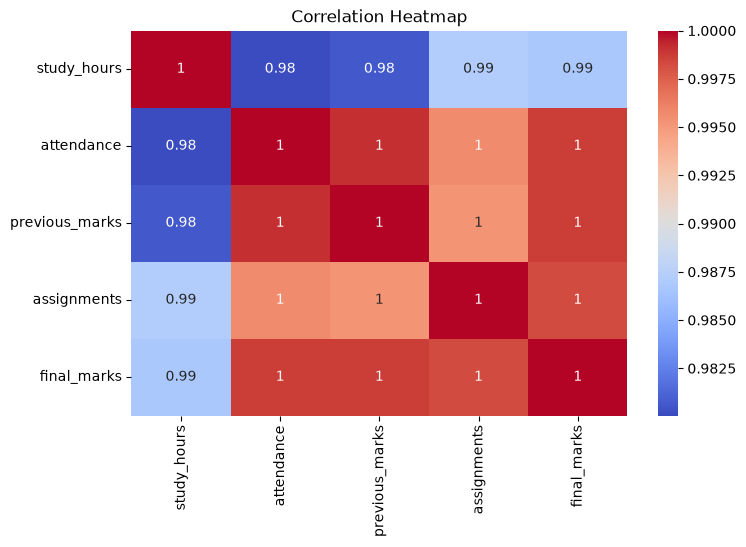

In [14]:
plt.figure(figsize=(8, 5))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

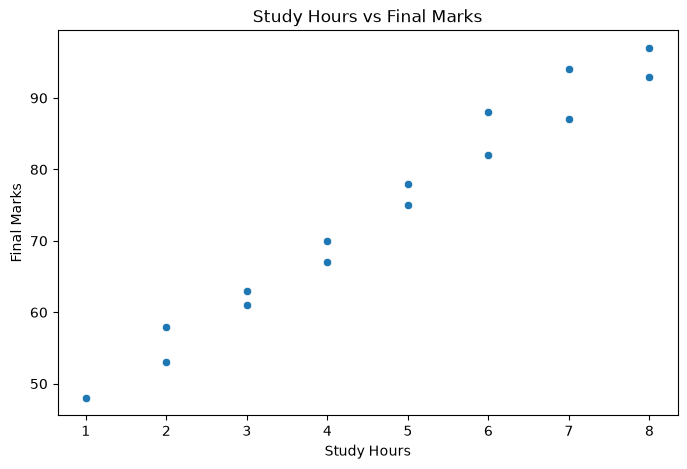

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="study_hours",
    y="final_marks",
    data=data
)
plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.show()

In [16]:
X = data[["study_hours", "attendance", "previous_marks", "assignments"]]

In [17]:
y = data ["final_marks"]

In [18]:
X.head()

,study_hours,attendance,previous_marks,assignments
0,2,60,55,50
1,3,65,60,55
2,4,70,65,65
3,5,75,70,70
4,6,80,75,80


In [19]:
y.head()

0    58
1    63
2    70
3    75
4    82
Name: final_marks, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [23]:
print("Training data:", X_train.shape)
print("Testing data:", y_test.shape)

Training data: (12, 4)
Testing data: (3,)


In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [25]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.66,0.27,0.39,0.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['study_hours','attendance','previous_marks','assignments']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.675
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [26]:
y_pred = model.predict(X_test)

In [32]:
comparison = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred})
comparison

,Actual Marks,Predicted Marks
0,67,66.702644
1,88,88.196438
2,58,57.709120


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 0.26155783414283224
MSE: 0.0705397731657858
R2 Score: 0.9995535457394571


In [36]:
import joblib
joblib.dump(model, "../model/student_performance_model.pkl")

['../model/student_performance_model.pkl']

In [37]:
loaded_model = joblib.load("../model/student_performance_model.pkl")

In [40]:
new_student = [[6, 80, 75, 80]]

In [42]:
prediction = loaded_model.predict(new_student)
print("Predicted Final Marks:", prediction[0])

Predicted Final Marks: 81.8882892606584


C:\Users\laptop valley\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
